In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

# Configure visual defaults
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100


In [2]:
# Load and prepare the sales data
df = pd.read_csv("sales_data.csv")
# Invalid placeholders such as '2026-07-XX' become missing dates.
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Date-derived features
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Year_Month"] = df["Order_Date"].dt.to_period("M")

# Dataset diagnostics
df.info()
display(df.isna().sum())

invalid_date_rows = df[df["Order_Date"].isna()]
if not invalid_date_rows.empty:
    print("Rows with invalid Order_Date values:")
    display(invalid_date_rows)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       51 non-null     int64         
 1   Order_Date     50 non-null     datetime64[ns]
 2   Customer_Name  51 non-null     object        
 3   City           51 non-null     object        
 4   Category       51 non-null     object        
 5   Product        51 non-null     object        
 6   Quantity       51 non-null     int64         
 7   Unit_Price     51 non-null     int64         
 8   Discount       51 non-null     float64       
 9   Payment_Mode   51 non-null     object        
 10  Sales          51 non-null     float64       
 11  Year           50 non-null     float64       
 12  Month          50 non-null     float64       
 13  Year_Month     50 non-null     period[M]     
dtypes: datetime64[ns](1), float64(4), int64(3), object(5), period[M](1)
memory u

Order_ID         0
Order_Date       1
Customer_Name    0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Discount         0
Payment_Mode     0
Sales            0
Year             1
Month            1
Year_Month       1
dtype: int64

Rows with invalid Order_Date values:


,Order_ID,Order_Date,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount,Payment_Mode,Sales,Year,Month,Year_Month
47,1048,NaT,Rahul Verma,Mumbai,Stationery,Notebook,40,120,0.05,Cash,4560.0,NaN,NaN,NaT


In [3]:
# Core business KPIs
total_revenue = np.sum(df["Sales"])
total_orders = df["Order_ID"].nunique()
average_order_value = np.mean(df["Sales"])
total_units_sold = np.sum(df["Quantity"])

kpis = pd.Series({
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Average Order Value": average_order_value,
    "Total Units Sold": total_units_sold
})
display(kpis)


Total Revenue          312456.500000
Total Orders               50.000000
Average Order Value      6126.598039
Total Units Sold          422.000000
dtype: float64

In [4]:
# Category-level sales summary
category_summary = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Mean_Discount=("Discount", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

display(category_summary)


,Total_Sales,Total_Quantity,Mean_Discount
Category,,,
Furniture,154002.0,28,0.112000
Electronics,119757.5,143,0.057917
Stationery,34377.0,250,0.027273
Furniture,4320.0,1,0.100000


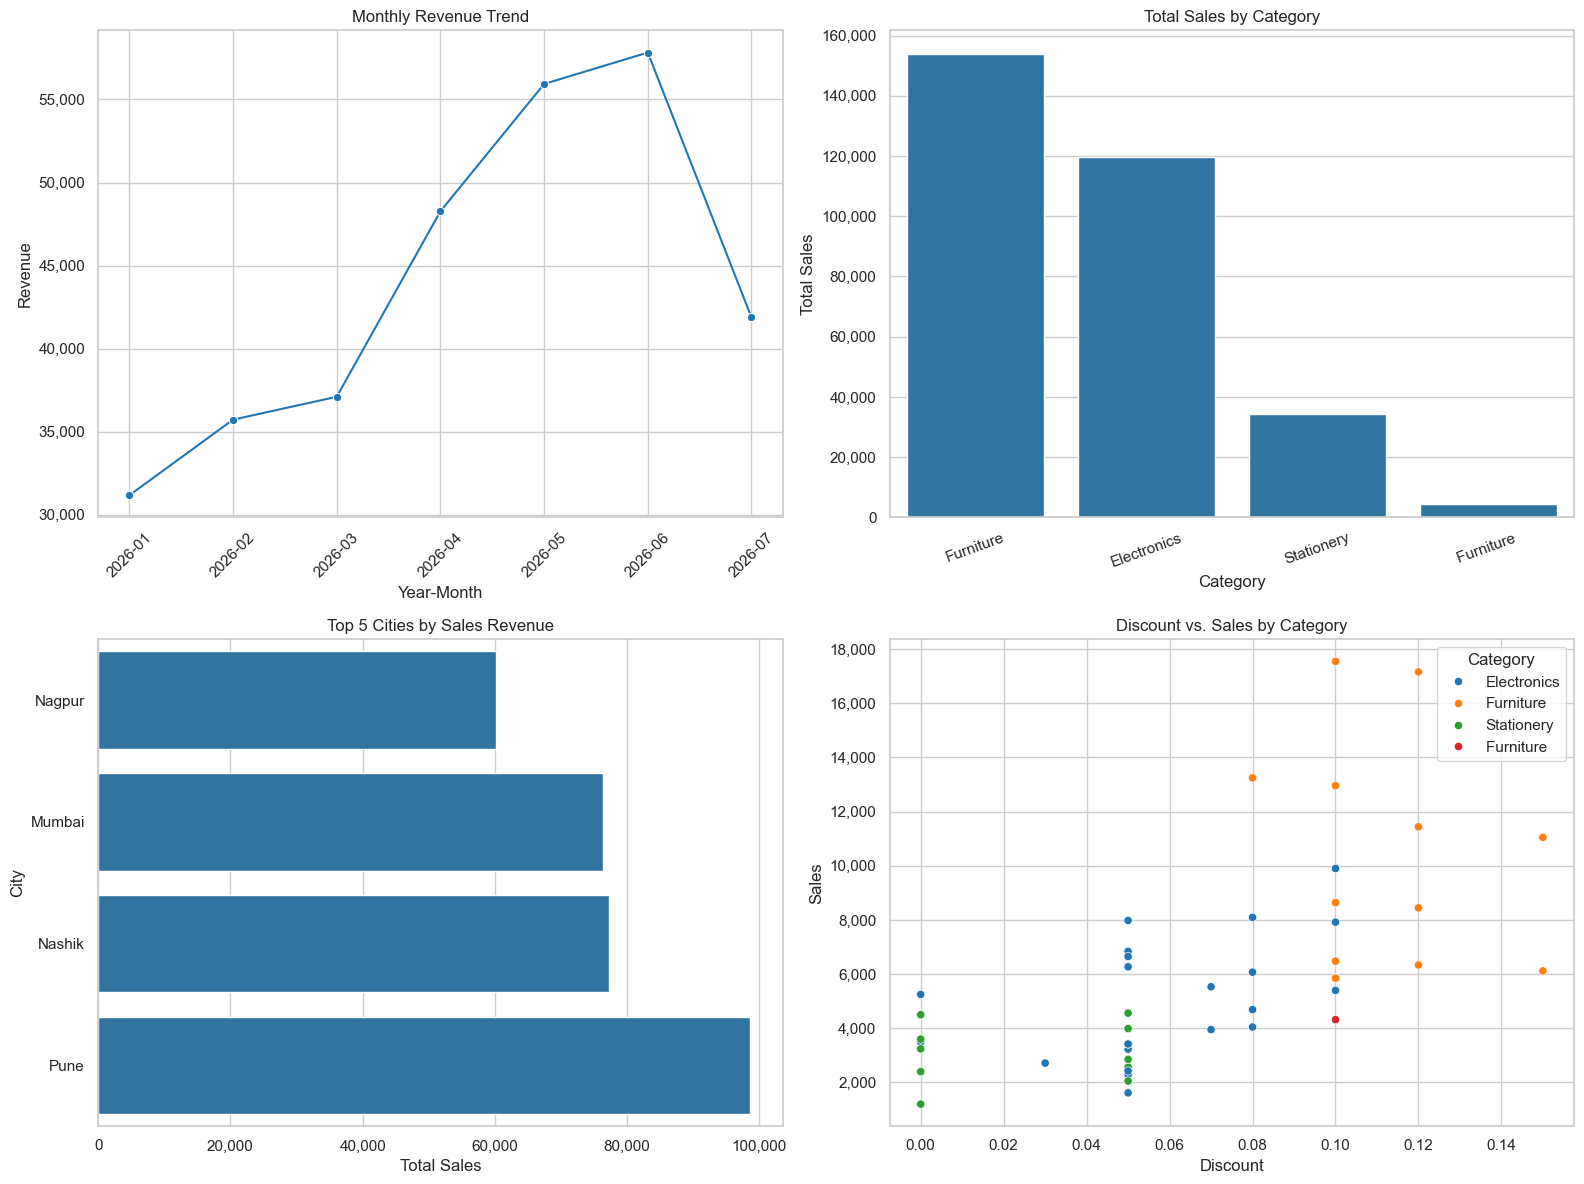

In [5]:
# Summaries for visual analysis
monthly_revenue = (
    df.groupby("Year_Month", as_index=False)["Sales"]
    .sum()
    .sort_values("Year_Month")
)
monthly_revenue["Year_Month"] = monthly_revenue["Year_Month"].astype(str)

top_cities = (
    df.groupby("City", as_index=False)["Sales"]
    .sum()
    .nlargest(5, "Sales")
    .sort_values("Sales")
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Monthly revenue trend
sns.lineplot(data=monthly_revenue, x="Year_Month", y="Sales", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].set_xlabel("Year-Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Sales by category
sns.barplot(data=category_summary.reset_index(), x="Category", y="Total_Sales", ax=axes[0, 1])
axes[0, 1].set_title("Total Sales by Category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Total Sales")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3. Top cities by revenue
sns.barplot(data=top_cities, x="Sales", y="City", ax=axes[1, 0])
axes[1, 0].set_title("Top 5 Cities by Sales Revenue")
axes[1, 0].set_xlabel("Total Sales")
axes[1, 0].set_ylabel("City")

# 4. Discount versus sales
sns.scatterplot(data=df, x="Discount", y="Sales", hue="Category", ax=axes[1, 1])
axes[1, 1].set_title("Discount vs. Sales by Category")
axes[1, 1].set_xlabel("Discount")
axes[1, 1].set_ylabel("Sales")
axes[1, 1].legend(title="Category")

axes[0, 0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0, 1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1, 0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1, 1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()
